# 📊 Project 5: AI4I 2020 Predictive Maintenance - Exploratory Data Analysis (EDA)
**TechTrek Advanced Data Science & AI Graduation Project**

This notebook contains comprehensive Exploratory Data Analysis (EDA), statistical summary, target imbalance inspection, physical feature engineering, and visualization for the **AI4I 2020 Predictive Maintenance Dataset**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load Raw Dataset
df_raw = pd.read_csv("../ai4i2020.csv")
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Dataset Shape: 10000 rows, 14 columns


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Dataset Overview & Data Quality Checks

In [2]:
# Missing Values and Data Types
print("--- Missing Values Check ---")
print(df_raw.isnull().sum())
print("\n--- Data Summary ---")
df_raw.describe()

--- Missing Values Check ---
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

--- Data Summary ---


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 2. Target Imbalance Analysis (`Machine failure`)

C:\Users\thest\AppData\Local\Temp\ipykernel_21112\3802220208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_raw, x="Machine failure", palette="viridis")


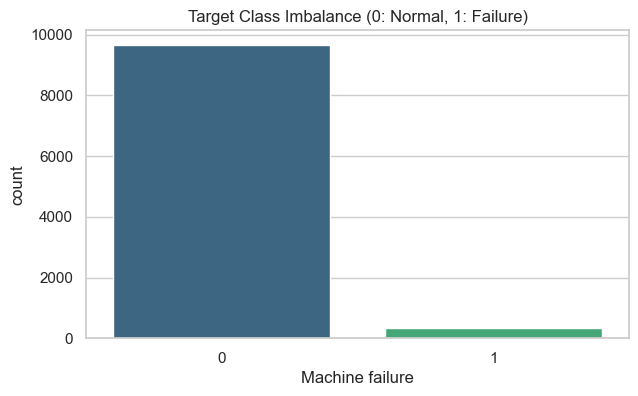

In [3]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df_raw, x="Machine failure", palette="viridis")
plt.title("Target Class Imbalance (0: Normal, 1: Failure)")
plt.show()

## 3. Failure Modes Breakdown (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`)

C:\Users\thest\AppData\Local\Temp\ipykernel_21112\585654052.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=failures_sum, x="Failure Mode", y="Count", palette="rocket")


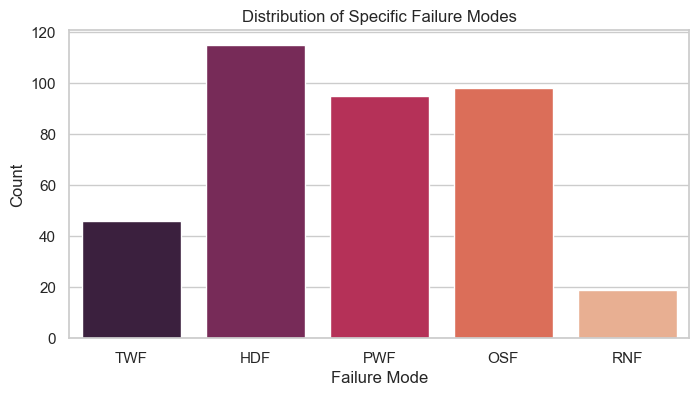

In [4]:
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
failures_sum = df_raw[failure_cols].sum().reset_index()
failures_sum.columns = ["Failure Mode", "Count"]

plt.figure(figsize=(8, 4))
sns.barplot(data=failures_sum, x="Failure Mode", y="Count", palette="rocket")
plt.title("Distribution of Specific Failure Modes")
plt.show()

## 4. Physical Feature Engineering Analysis

C:\Users\thest\AppData\Local\Temp\ipykernel_21112\1988076184.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eng, x="Machine failure", y="Temp_Diff", ax=axes[0], palette="Set2")
C:\Users\thest\AppData\Local\Temp\ipykernel_21112\1988076184.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eng, x="Machine failure", y="Power_W", ax=axes[1], palette="Set2")
C:\Users\thest\AppData\Local\Temp\ipykernel_21112\1988076184.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eng, x="Machine failure", y="Tool_Wear_Strain"

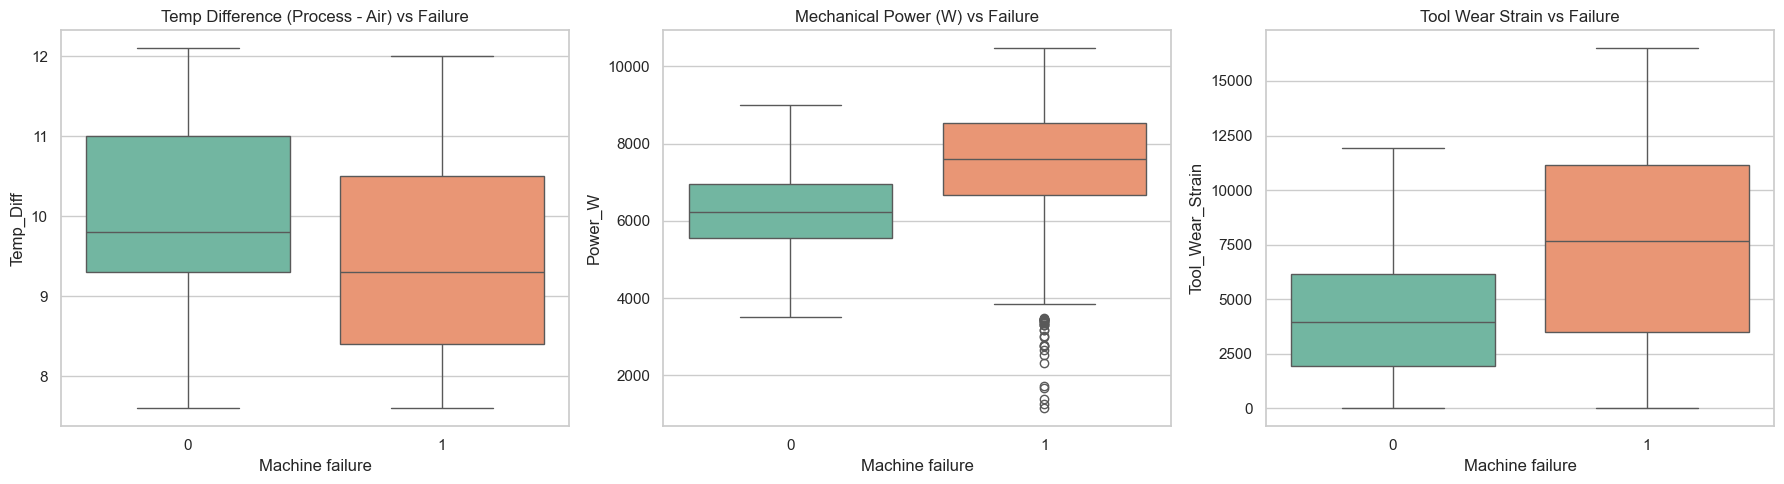

In [5]:
df_eng = df_raw.copy()
df_eng["Temp_Diff"] = df_eng["Process temperature [K]"] - df_eng["Air temperature [K]"]
df_eng["Power_W"] = df_eng["Torque [Nm]"] * df_eng["Rotational speed [rpm]"] * (2 * np.pi / 60)
df_eng["Tool_Wear_Strain"] = df_eng["Tool wear [min]"] * df_eng["Torque [Nm]"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df_eng, x="Machine failure", y="Temp_Diff", ax=axes[0], palette="Set2")
axes[0].set_title("Temp Difference (Process - Air) vs Failure")

sns.boxplot(data=df_eng, x="Machine failure", y="Power_W", ax=axes[1], palette="Set2")
axes[1].set_title("Mechanical Power (W) vs Failure")

sns.boxplot(data=df_eng, x="Machine failure", y="Tool_Wear_Strain", ax=axes[2], palette="Set2")
axes[2].set_title("Tool Wear Strain vs Failure")
plt.tight_layout()
plt.show()

## 5. Feature Correlation Heatmap

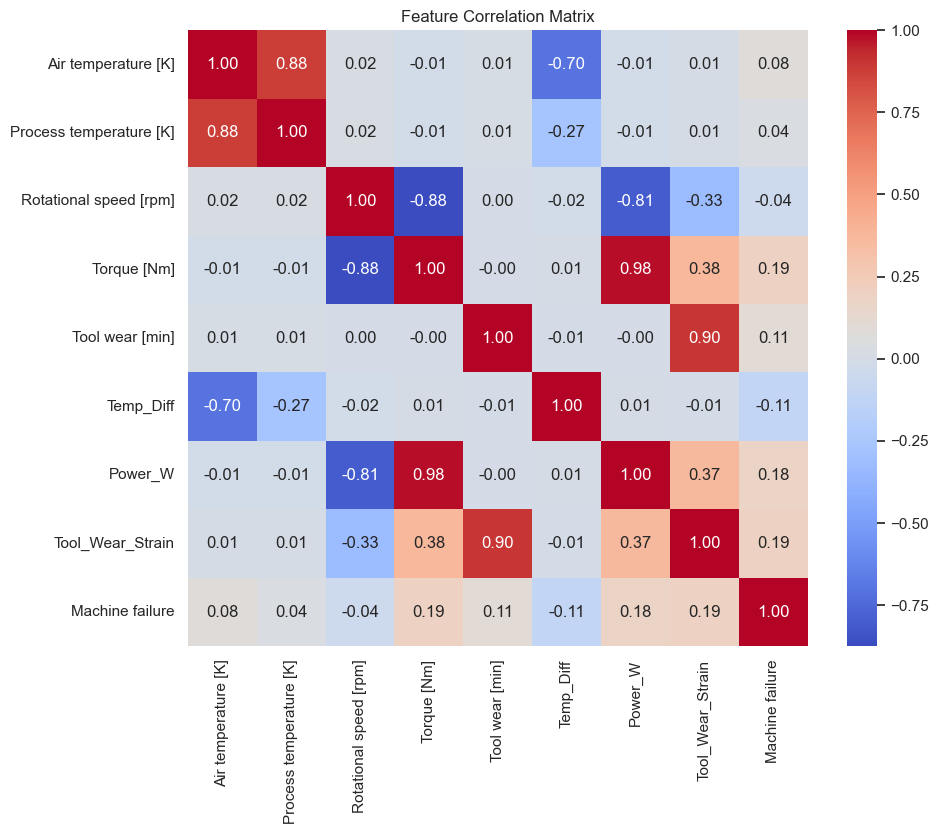

In [6]:
num_cols = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", "Temp_Diff", "Power_W", "Tool_Wear_Strain", "Machine failure"]
plt.figure(figsize=(10, 8))
sns.heatmap(df_eng[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Matrix")
plt.show()